# Week 7 – Mini Project 1 (Non-Graded)


<hr class=red-dashed-ruler>

## Set ups 
<hr class=red-dashed-ruler>

In [15]:
!jupyter nbconvert --to script ../utlities.ipynb

[NbConvertApp] Converting notebook ../utlities.ipynb to script
[NbConvertApp] Writing 4659 bytes to ..\utlities.py


<hr class=red-dashed-ruler>

This is a practice mini project and is not graded, nor will it count towards program
completion. However, we strongly recommend completing it to build your understanding of
probability concepts and their application to real-world quality control scenarios.
This project focuses on applying basic probability and statistics to a manufacturing defect
inspection dataset. You will calculate probabilities, conditional probabilities, and
independence tests, along with visual analysis of defect patterns across shifts.


<hr class=red-dashed-ruler>

Case Study – Defect Inspection
You will be working with:
• Mini_Project_1_DefectInspection.csv
The objective of this activity is to analyze defect data from a manufacturing process,
estimate probabilities of different defect types, and identify potential dependencies
between shifts and defect occurrences.

<hr class=red-dashed-ruler>

How to approach this mini project:
1. Load the dataset into your preferred analytics tool (e.g., Python, Excel, Power BI).
2. Review the structure of the dataset, noting columns such as DefectA, DefectB,
and Shift.
3. Perform each calculation step-by-step, interpreting what each probability
represents.
4. Use visuals (such as bar charts or contingency tables) to understand patterns and
dependencies.
5. Reflect on how observed data might differ from theoretical probabilities in practice.


<hr class=red-dashed-ruler>

Key tip:
 Focus on understanding joint, marginal, and conditional probabilities, as well as how to
interpret independence in categorical data such as shifts and defect types.

<hr class=red-dashed-ruler>

## Initial Steps

In [4]:
import pandas as pd 
df=pd.read_csv("data/Mini_Project_1_DefectInspection.csv")
print(df.head())

   ItemID  DefectTypeA  DefectTypeB    Shift
0       1            0            0  Morning
1       2            0            0  Evening
2       3            0            1  Evening
3       4            0            0  Morning
4       5            0            0  Evening


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ItemID       100 non-null    int64 
 1   DefectTypeA  100 non-null    int64 
 2   DefectTypeB  100 non-null    int64 
 3   Shift        100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


<hr class=red-dashed-ruler>

## Mini Project 1 – Defect Inspection: Questions
You are part of a Quality Control team tasked with analyzing inspection data from a
manufacturing line. Use the dataset Mini Project1_DefectInspection.csv to answer the
following questions:


<hr class=red-dashed-ruler>

### Q1 : What is the probability of an item having Defect Type A?

In [76]:
P_A= df['DefectTypeA'].mean()
print(P_A)

P_B= df['DefectTypeB'].mean()
print(P_B)

0.14
0.09


<hr class=red-dashed-ruler>

### Q2 : What is the probability of an item having both Defect A and B?

In [12]:
joint = ((df['DefectTypeA'] == 1) & 
             (df['DefectTypeB'] == 1)).mean()

print(joint)

0.01


<hr class=red-dashed-ruler>

### Q3 : What is P(Defect B | Defect A) — the conditional probability of having Defect B given Defect A?

P(B∣A)=P(A) P(A∩B)

In [13]:
p_b_given_a = P_A*joint
print (p_b_given_a)

0.0014000000000000002


<hr class=red-dashed-ruler>

### Q4 : How many items are defect-free (no Defect A or B)?

In [15]:
num_defect_free = ((df['DefectTypeA'] == 0) & 
                   (df['DefectTypeB'] == 0)).sum()

print(num_defect_free)

78


<hr class=red-dashed-ruler>

### Q5: What proportion of defects occur in the Morning shift?

In [30]:
defective_df = df[
    (df['DefectTypeA'] == 1) | 
    (df['DefectTypeB'] == 1)
]

prop_morning_defects = (defective_df['Shift'] == 'Morning').mean()

print(prop_morning_defects)

0.5909090909090909


<hr class=red-dashed-ruler>

### Q6 : Create a contingency table for Shift vs DefectA.

In [31]:
pd.crosstab(df.Shift,df.DefectTypeA)

DefectTypeA,0,1
Shift,,
Evening,38,5
Morning,48,9


<hr class=red-dashed-ruler>

### Q7 : Test independence: Are defects and shift independent? Use proportions to assess.

In [ ]:
P(A Given Shift is Morning)
P(A)
PA

In [53]:
print(P_A)
p_A_given_morning= df[df["Shift"]=="Morning"]['DefectTypeA'].mean()
print(p_A_given_morning)
p_A_given_evening= df[df["Shift"]=="Evening"]['DefectTypeA'].mean()
print(p_A_given_evening)


0.14
0.15789473684210525
0.11627906976744186


Since P(A) is not same as P(A) given morning, there is depndency.

<hr class=red-dashed-ruler>

### Q8 : Estimate the joint probability of A and B occurring together.

Same as Question 2

<hr class=red-dashed-ruler>

### Q9 : Visualize shift-wise defect counts using a bar chart.

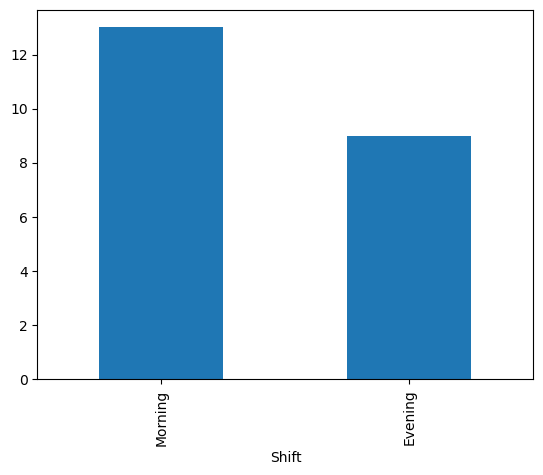

In [73]:
defective_df = df[
    (df['DefectTypeA'] == 1) | 
    (df['DefectTypeB'] == 1)
]

shift_defect=defective_df['Shift'].value_counts()
shift_defect.plot(kind='bar')
plt.show()

<Axes: title={'center': 'defects by Shift'}, xlabel='Shift'>

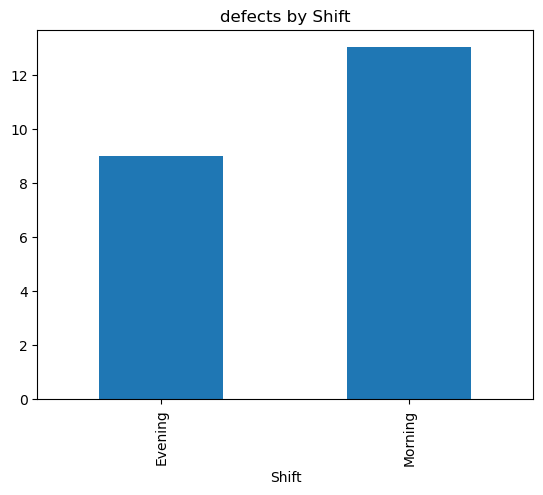

In [75]:
df[(df['DefectTypeA'] == 1) | (df['DefectTypeB'] == 1)].groupby('Shift').size().plot(kind='bar', title = "defects by Shift")




<hr class=red-dashed-ruler>

### Q10  - What is the probability of an item having at least one defect?

P(A union B) = P(A)+P(B) - P(A and B) 

In [95]:
print(P_A+P_B-joint)

0.22


In [92]:
df['either_defect'] = (df['DefectTypeA'] == 1 ) |  (df['DefectTypeB'] == 1)

In [93]:
print(df['either_defect'].mean())

np.float64(0.22)

Both are same

<hr class=red-dashed-ruler>

### Q11 : Estimate the expected defect count per item.

In [98]:
df['defect_count'] = df['DefectTypeA'] +  df['DefectTypeB'] 

In [100]:
print(df['defect_count'].mean())

0.23


Estimate expected defect count per item:
Approximation: 
E(X)=P(A)+P(B)

In [101]:
P_A+P_B

np.float64(0.23)

AttributeError: 'list' object has no attribute 'mean'

<hr class=red-dashed-ruler>

### Q12 : Compare marginal probabilities of DefectA and DefectB.

In [106]:
print(P_A)
print(P_B)


0.14
0.09


<hr class=red-dashed-ruler>

### Q13 : Estimate conditional probabilities: P(DefectA | Shift = Morning) and P(DefectA | Shift = Evening)

In [107]:
p_a_morning = df.loc[df['Shift'] == 'Morning', 'DefectTypeA'].mean()

p_a_evening = df.loc[df['Shift'] == 'Evening', 'DefectTypeA'].mean()

p_a_morning, p_a_evening

(np.float64(0.15789473684210525), np.float64(0.11627906976744186))

In [108]:
df.loc[df['Shift'] == 'Morning', 'DefectTypeA']

0     0
3     0
6     0
9     0
10    0
11    1
12    1
13    0
15    0
16    1
17    0
18    0
21    0
22    0
26    1
27    0
28    0
31    1
32    1
33    0
35    1
37    0
38    0
39    0
40    0
41    0
44    1
45    0
49    0
53    0
54    0
56    0
57    0
58    0
59    0
61    0
62    0
64    1
65    0
66    0
68    0
70    0
71    0
74    0
77    0
78    0
79    0
84    0
85    0
86    0
91    0
92    0
93    0
94    0
96    0
98    0
99    0
Name: DefectTypeA, dtype: int64

<hr class=red-dashed-ruler>

### Q14 : What is P(no defects)?

In [110]:
P_no_defect = num_defect_free/len(df)
print(P_no_defect)

0.78


<hr class=red-dashed-ruler>

### Q15 : Discuss: What real-world factors could cause deviation from theoretical probabilities?

In [ ]:
Bias, Shift Fatigue etc...


<hr class=red-dashed-ruler>